#### Advanced Computer Vision Techniques

### 0. Requirements

In [ ]:
%load_ext autoreload
%autoreload 2

import os

# Set project root
repo_name = "transfer_learning"
os.chdir(os.getcwd().split(repo_name)[0] + repo_name)
print(f'Changed working directory to: {os.getcwd()}')

# Python modules
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
import torch.optim as optim
import matplotlib.pyplot as plt

# Local modules
from src.data_loaders import load_cifar10, make_dataloaders
from src.models import build_vgg, build_resnet, build_inception
from src.model_training import train_model
from src.utils import display_images


# ---------- Setup for reproducibility ----------
seed = 28
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")

Changed working directory to: c:\Users\EMILIO\Desktop\Unversidad de la Sabana (Profesor)\Semestre 4\transfer_learning
PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8


### 1. Load Data

In [2]:
train_ds, val_ds, test_ds = load_cifar10()

c:\Users\EMILIO\Desktop\Unversidad de la Sabana (Profesor)\Semestre 4\transfer_learning\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Training samples: 45000
Validation samples: 5000
Test samples: 10000


### 2. Training pipelines for different models

#### 2.1. Inception Model

##### 2.1.1 Setting Model and Data Loaders

In [ ]:
# --- Experiment Parameters ---
batch_size = 256
model_name = "inception"  # Options: "vgg", "resnet", "inception"
num_classes = 10
epochs = 6
lr_feature_extraction = 1e-3

model = build_inception()

In [4]:
model

Inception3(
  (Conv2d_1a_3x3): BasicConv2d(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2a_3x3): BasicConv2d(
    (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_2b_3x3): BasicConv2d(
    (conv): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(64, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (maxpool1): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  (Conv2d_3b_1x1): BasicConv2d(
    (conv): Conv2d(64, 80, kernel_size=(1, 1), stride=(1, 1), bias=False)
    (bn): BatchNorm2d(80, eps=0.001, momentum=0.1, affine=True, track_running_stats=True)
  )
  (Conv2d_4a_3x3): BasicConv2d(
    (conv): Conv2d(80, 192, kernel_size=(3, 3), stri

cuda
✅ mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]


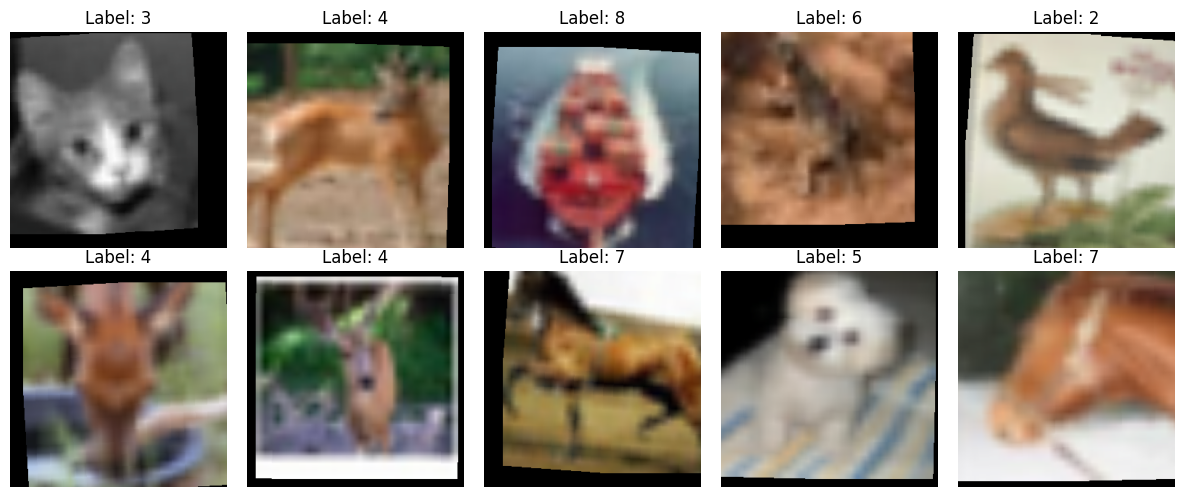

In [ ]:
# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr_feature_extraction)

# Data Loaders
train_loader, val_loader, test_loader, mean, std = make_dataloaders(
    train_ds, val_ds, test_ds, batch_size=batch_size, model_name="inception", augment=True
)

# Get one batch
images, labels = next(iter(train_loader))
display_images(images, labels, mean, std)

##### 2.1.2 Training (Transfer Learning)

In [6]:
train_model(model, model_name, train_loader, val_loader, criterion, optimizer, device, epochs)

Epoch [1/6] Train Loss: 1.7979 | Train Acc: 55.06% | Val Loss: 0.8919 | Val Acc: 72.70%


Epoch [2/6] Train Loss: 1.3977 | Train Acc: 63.46% | Val Loss: 0.8096 | Val Acc: 73.48%


Epoch [3/6] Train Loss: 1.3507 | Train Acc: 64.17% | Val Loss: 0.7619 | Val Acc: 75.10%


Epoch [4/6] Train Loss: 1.3240 | Train Acc: 64.61% | Val Loss: 0.7646 | Val Acc: 73.72%


Epoch [5/6] Train Loss: 1.3141 | Train Acc: 64.48% | Val Loss: 0.7465 | Val Acc: 74.72%


Epoch [6/6] Train Loss: 1.3068 | Train Acc: 64.43% | Val Loss: 0.7177 | Val Acc: 75.74%


([1.7978546890345486,
  1.3977093168280341,
  1.3507106730883771,
  1.3240342363715172,
  1.314107285304503,
  1.306766924532977],
 [0.891907376050949,
  0.8096396654844285,
  0.7619262307882309,
  0.7645551025867462,
  0.7465074211359024,
  0.7177271485328675],
 [55.06,
  63.455555555555556,
  64.17333333333333,
  64.60666666666667,
  64.48222222222222,
  64.43111111111111],
 [72.7, 73.48, 75.1, 73.72, 74.72, 75.74])

##### 2.1.3 Training Fine Tunning

If `DO_FINETUNE` is `True`, it unfreezes some of the top layers of the base model. It then re-compiles the model with a very low learning rate and trains for a few more epochs. This allows the model to slightly adjust the pre-trained features to better suit the specifics of the CIFAR-10 dataset, often leading to a boost in accuracy. It's crucial that `BatchNormalization` layers remain frozen during this process.

In [13]:
DO_FINETUNE = True
MODEL_CHOICE = "inception"
LR_FINETUNE = 1e-4

if DO_FINETUNE:
    print("\n--- Activating Partial Fine-Tuning ---")

    # ========================
    # Unfreeze strategy by model (freeze BatchNorm always)
    # ========================
    if MODEL_CHOICE == "vgg":
        # Unfreeze last N layers in the VGG feature extractor, EXCEPT BatchNorm
        fine_tune_at = 15
        # Assume model[0] is the VGG backbone
        vgg_features = model[0].features
        for idx in range(fine_tune_at, len(vgg_features)):
            m = vgg_features[idx]
            for param in m.parameters(recurse=True):
                # Only update if not BatchNorm
                if not isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                    param.requires_grad = True
    elif MODEL_CHOICE == "resnet":
        # For resnet, unfreeze layer4 (aka conv5_block in Keras) except BatchNorm layers
        resnet_base = model[0]
        for name, m in resnet_base.layer4.named_modules():
            if not isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                for param in m.parameters(recurse=False):
                    param.requires_grad = True
    elif MODEL_CHOICE == "inception":
        # For inception, unfreeze Mixed_7b and Mixed_7c except BatchNorm
        inception_base = model
        # Unfreeze last two "Mixed" blocks
        for layer_name in ["Mixed_7b", "Mixed_7c"]:
            mixed_layer = getattr(inception_base, layer_name, None)
            if mixed_layer is not None:
                for m in mixed_layer.modules():
                    if not isinstance(m, torch.nn.modules.batchnorm._BatchNorm):
                        for param in m.parameters(recurse=False):
                            param.requires_grad = True
    else:
        raise ValueError("Unknown MODEL_CHOICE for fine-tuning")
            
    # Re-train/re-"compile" with a lower LR for only unfrozen (requires_grad) params
    print(f"Fine-tuning with learning rate = {LR_FINETUNE}...")
    fine_tune_epochs = 1 #max(3, epochs // 2)
    finetune_params = [p for p in model.parameters() if p.requires_grad]
    optimizer_ft = optim.Adam(finetune_params, lr=LR_FINETUNE)

    # Train for more epochs
    train_model(
        model, f"{model_name}_finetune", train_loader, val_loader,
        criterion, optimizer_ft, device,
        fine_tune_epochs
    )

    from src.model_training import evaluate

    print("\n--- Evaluating after Fine-Tuning ---")
    val_loss, val_acc = evaluate(model, test_loader, criterion, device)
    print(f"Fine-Tuning Test Loss: {val_loss:.4f} | Test Acc: {val_acc:.2f}%")


--- Activating Partial Fine-Tuning ---
Fine-tuning with learning rate = 0.0001...


Epoch [1/1] Train Loss: 0.5943 | Train Acc: 88.95% | Val Loss: 0.2781 | Val Acc: 90.48%

--- Evaluating after Fine-Tuning ---
Fine-Tuning Test Loss: 0.2728 | Test Acc: 90.84%


**3. Explainable AI - Grad-CAM Visualization**

Finally, it takes a sample image from the test set, generates the Grad-CAM overlay using the fully trained model, and saves the resulting image to the `outputs` directory.


--- Generating Grad-CAM Visualization ---
Using device: cuda:0
Using Grad-CAM layer: Mixed_7c
Grad-CAM image saved to: output\inception_finetune_gradcam.png


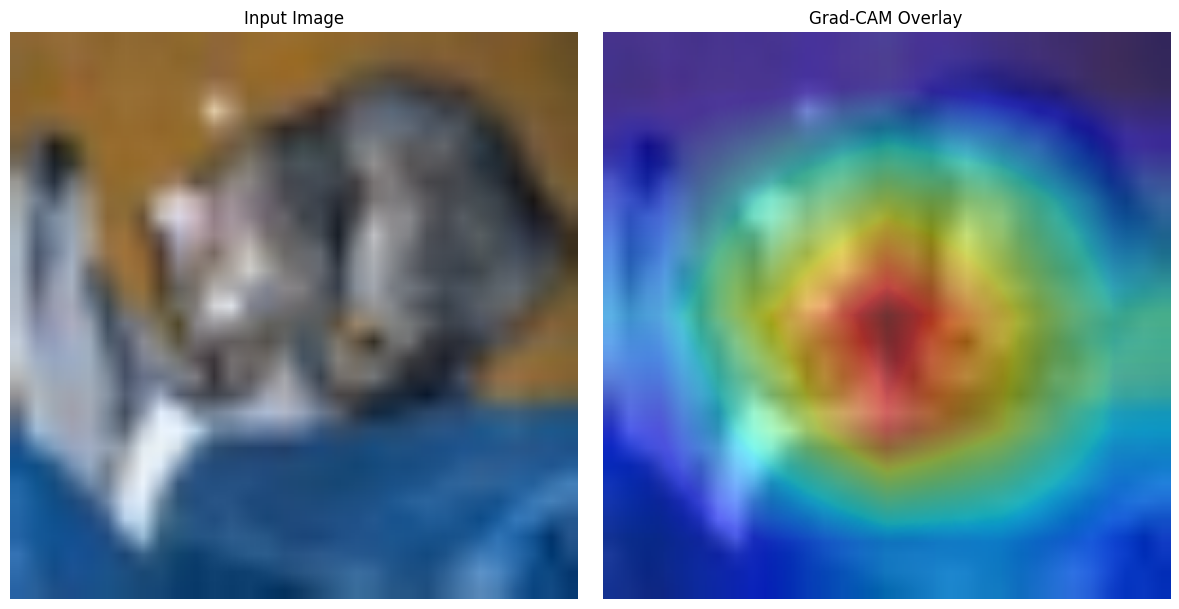

In [16]:
import os
import imageio
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn.functional as F

from src.xai import (
    attach_hooks,
    run_forward,
    run_backward,
    compute_gradcam,
    resize_cam,
    tensor_to_uint8,
)

print("\n--- Generating Grad-CAM Visualization ---")

# ------------------------------------------------------------
# Config
# ------------------------------------------------------------
OUT_DIR = "output"
os.makedirs(OUT_DIR, exist_ok=True)

image_size = (224, 224)

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------
device = next(model.parameters()).device
print(f"Using device: {device}")

# ------------------------------------------------------------
# Select one sample
# ------------------------------------------------------------
images, labels = next(iter(test_loader))

# Image tensor from loader: (C, H, W)
demo_image_t = images[0]

# Label
demo_label = labels[0]

# Save original size before resize
orig_H, orig_W = demo_image_t.shape[1:]

# ------------------------------------------------------------
# Visualization copy (H, W, C)
# ------------------------------------------------------------
demo_image = demo_image_t.permute(1, 2, 0).cpu().numpy()

# Normalize for visualization if needed
if demo_image.max() > 1.0:
    demo_image = demo_image / 255.0

# ------------------------------------------------------------
# Resize for model input if needed
# ------------------------------------------------------------
C, H, W = demo_image_t.shape

if (H, W) != tuple(image_size):
    demo_image_t = F.interpolate(
        demo_image_t.unsqueeze(0),
        size=image_size,
        mode="bilinear",
        align_corners=False,
    )[0]

# ------------------------------------------------------------
# Move image to same GPU/device as model
# ------------------------------------------------------------
demo_image_t = demo_image_t.unsqueeze(0).to(device)

# Ensure gradients enabled
demo_image_t.requires_grad_(True)

# ------------------------------------------------------------
# Select final convolution layer
# ------------------------------------------------------------
if MODEL_CHOICE == "vgg":
    last_conv_name = "features.29"

elif MODEL_CHOICE == "resnet":
    last_conv_name = "layer4.2.conv3"

elif MODEL_CHOICE == "inception":
    last_conv_name = "Mixed_7c"

else:
    raise ValueError(f"Unsupported MODEL_CHOICE: {MODEL_CHOICE}")

print(f"Using Grad-CAM layer: {last_conv_name}")

# ------------------------------------------------------------
# Attach hooks
# ------------------------------------------------------------
capture, remove = attach_hooks(model, last_conv_name)

# ------------------------------------------------------------
# Forward pass
# ------------------------------------------------------------
model.eval()

output, pred = run_forward(model, demo_image_t)

# ------------------------------------------------------------
# Backward pass
# ------------------------------------------------------------
run_backward(output, pred)

# ------------------------------------------------------------
# Get activations + gradients
# ------------------------------------------------------------
act = capture["act"]
grad = capture["grad"]

# ------------------------------------------------------------
# Compute Grad-CAM
# ------------------------------------------------------------
cam = compute_gradcam(act, grad)

# ------------------------------------------------------------
# Resize CAM to original image size
# ------------------------------------------------------------
if cam.shape != (orig_H, orig_W):
    cam = resize_cam(cam, orig_H, orig_W)

# ------------------------------------------------------------
# Convert original image for display
# ------------------------------------------------------------
orig_img_uint8 = tensor_to_uint8(
    torch.tensor(
        demo_image.transpose(2, 0, 1),
        dtype=torch.float32,
    )
)

# ------------------------------------------------------------
# Convert CAM to RGB heatmap
# ------------------------------------------------------------
cam_np = cam.detach().cpu().numpy()

# Clamp numerical noise
cam_np = np.clip(cam_np, 0.0, 1.0)

# Matplotlib colormap
cmap = plt.get_cmap("jet")

# RGBA -> RGB
heatmap_rgb = cmap(cam_np)[:, :, :3]

# Float [0,1] -> uint8 [0,255]
heatmap_rgb = (heatmap_rgb * 255).astype(np.uint8)

# ------------------------------------------------------------
# Blend original image + heatmap
# ------------------------------------------------------------
overlay = (
    0.5 * orig_img_uint8.astype(np.float32)
    + 0.5 * heatmap_rgb.astype(np.float32)
)

overlay = np.clip(overlay, 0, 255).astype(np.uint8)

# ------------------------------------------------------------
# Output filename
# ------------------------------------------------------------
output_filename = (
    f"{model_name}_finetune_gradcam.png"
    if DO_FINETUNE
    else f"{model_name}_gradcam.png"
)

out_path = os.path.join(OUT_DIR, output_filename)

# ------------------------------------------------------------
# Save image
# ------------------------------------------------------------
try:
    imageio.imwrite(out_path, overlay)

    print(f"Grad-CAM image saved to: {out_path}")

except Exception as e:
    print(f"Could not save Grad-CAM image: {e}")

# ------------------------------------------------------------
# Display
# ------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(12, 6),
)

ax1.imshow(orig_img_uint8)
ax1.set_title("Input Image")
ax1.axis("off")

ax2.imshow(overlay)
ax2.set_title("Grad-CAM Overlay")
ax2.axis("off")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Remove hooks
# ------------------------------------------------------------
remove()